In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## LOAD DATA

In [83]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [168]:
numeric_cols = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Physical_Activity'
]

categorical_cols = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Extracurricular_Activities',
    'Motivation_Level',
    'Internet_Access',
    'Family_Income',
    'Teacher_Quality',
    'School_Type',
    'Peer_Influence',
    'Learning_Disabilities',
    'Parental_Education_Level',
    'Distance_from_Home',
    'Gender'
]


In [86]:
df.describe()
     


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [87]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## Handling missing values 

In [122]:
df.isnull().mean() * 100

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
Hours_Studied_bin             0.000000
Attendance_bin                0.000000
Sleep_Hours_bin               0.000000
Previous_Scores_bin           0.000000
Tutoring_Sessions_bin         0.000000
Physical_Activity_bin    

In [101]:
#extract columns  with only nan vlaues 
all_nan_columns = df.columns[df.isna().any()].tolist()
df[all_nan_columns].dtypes

Teacher_Quality             object
Parental_Education_Level    object
Distance_from_Home          object
dtype: object

In [69]:
#apply imputer 
imputer = SimpleImputer(strategy="most_frequent")
for col in all_nan_columns :
    df[[col]] = imputer.fit_transform(df[[col]])
df.head()    

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [77]:
df.isna().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

## correlation 

In [79]:
df.corr(numeric_only=True)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


## data visualization

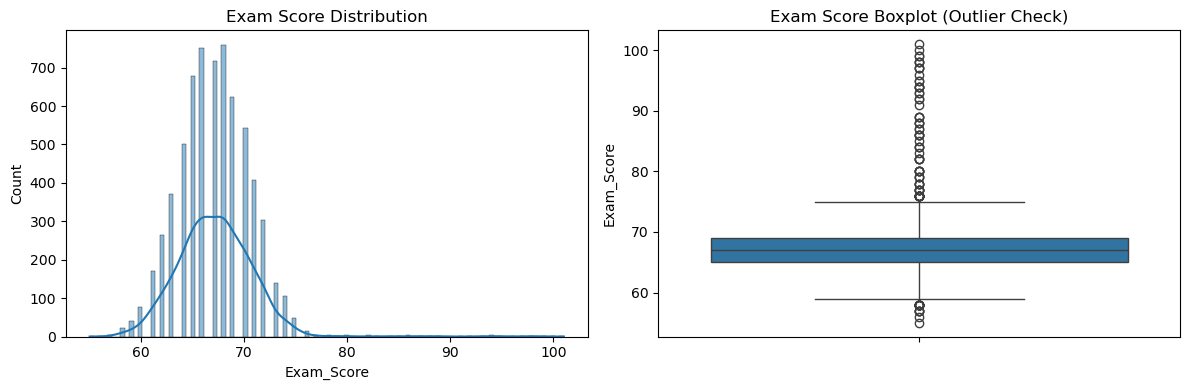

In [109]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)  
sns.histplot(df['Exam_Score'], kde=True)
plt.title('Exam Score Distribution')

plt.subplot(1, 2, 2)  
sns.boxplot(y=df['Exam_Score'])
plt.title('Exam Score Boxplot (Outlier Check)')

plt.tight_layout()
plt.show()

## CATEGORICAL FEATURES ANALYSIS 


📊 Gender:
         mean  median   std  count
Gender                            
Female  67.24    67.0  4.05   2793
Male    67.23    67.0  3.77   3814


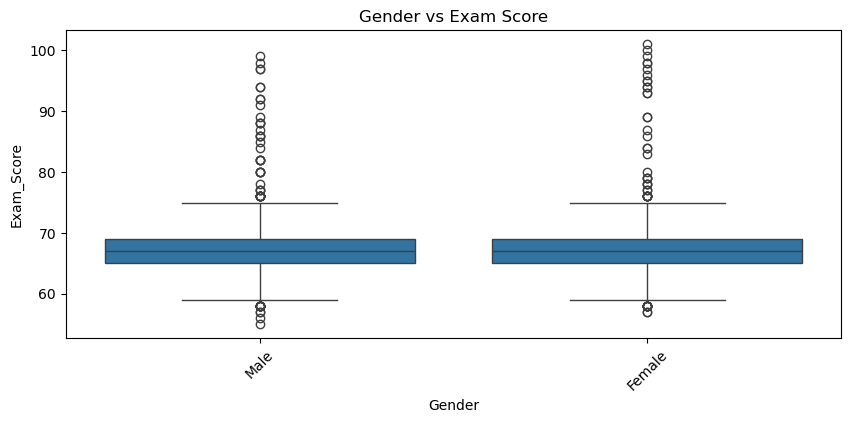


📊 School_Type:
              mean  median   std  count
School_Type                            
Private      67.29    67.0  3.85   2009
Public       67.21    67.0  3.91   4598


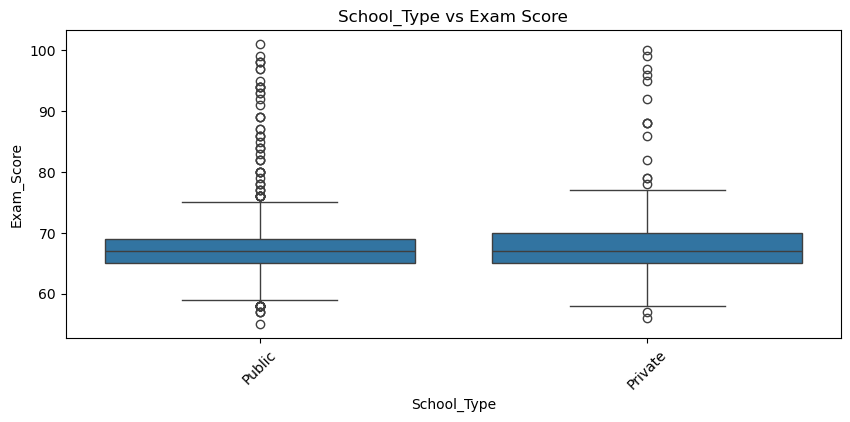


📊 Parental_Education_Level:
                           mean  median   std  count
Parental_Education_Level                            
Postgraduate              67.97    68.0  3.69   1305
College                   67.32    67.0  3.83   1989
High School               66.89    67.0  3.98   3223


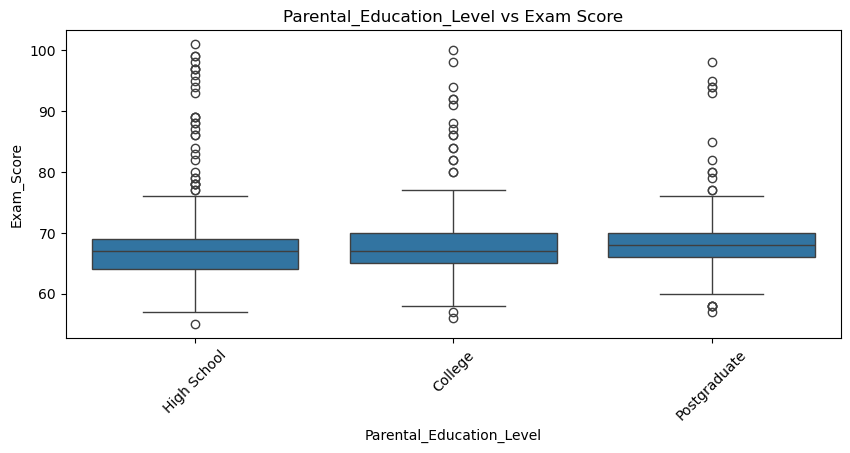


📊 Family_Income:
                mean  median   std  count
Family_Income                            
High           67.84    68.0  4.16   1269
Medium         67.33    67.0  3.81   2666
Low            66.85    67.0  3.80   2672


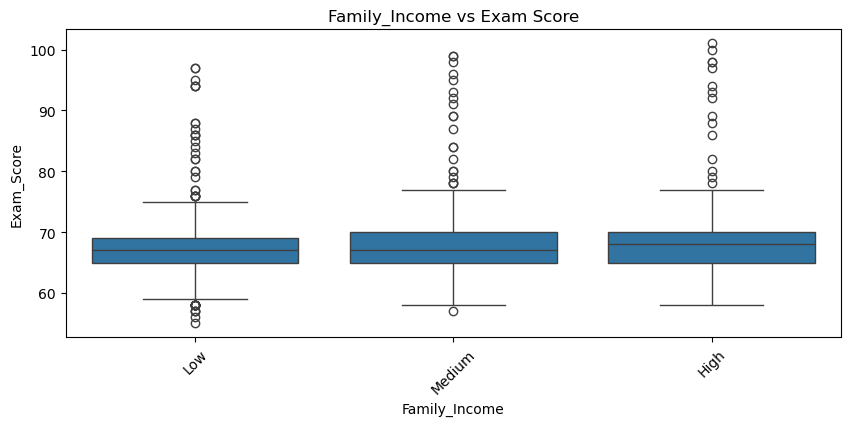


📊 Parental_Involvement:
                       mean  median   std  count
Parental_Involvement                            
High                  68.09    68.0  3.95   1908
Medium                67.10    67.0  3.73   3362
Low                   66.36    66.0  3.97   1337


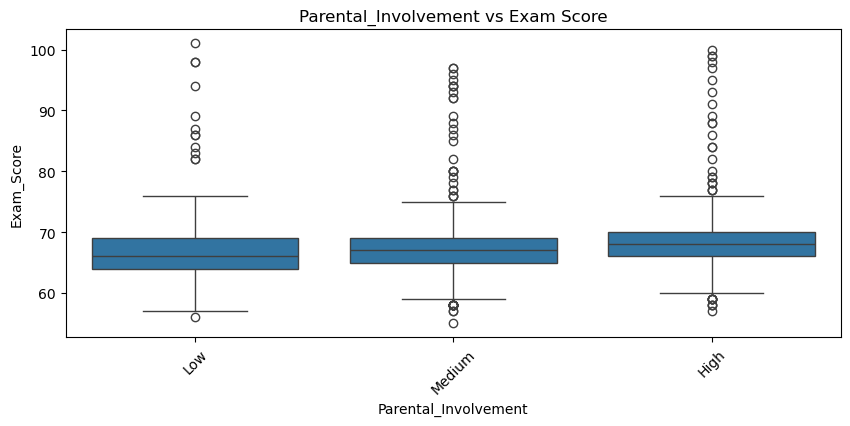


📊 Access_to_Resources:
                      mean  median   std  count
Access_to_Resources                            
High                 68.09    68.0  3.95   1975
Medium               67.13    67.0  3.87   3319
Low                  66.20    66.0  3.56   1313


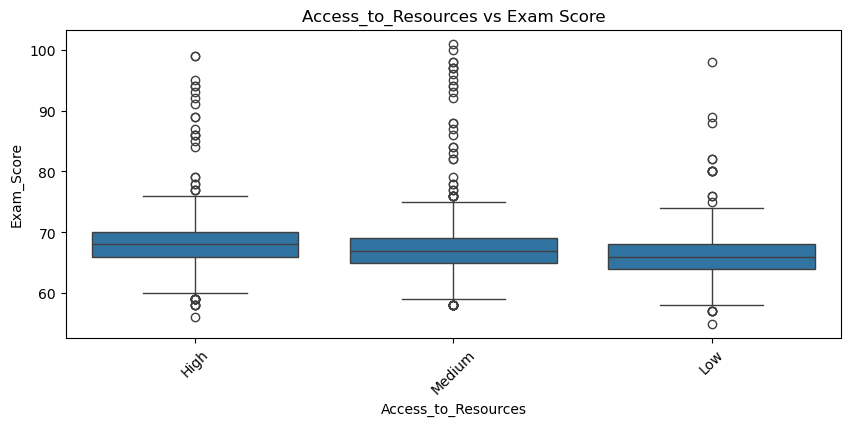

In [123]:

for col in categorical_cols[:6]:  # Show first 6 for brevity
    print(f"\n📊 {col}:")
    stats = df.groupby(col)["Exam_Score"].agg(['mean', 'median', 'std', 'count']).round(2)
    stats = stats.sort_values('mean', ascending=False)
    print(stats)
    
    # Visualization
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=col, y="Exam_Score", data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Exam Score')
    plt.show()

## NUMERICAL FEATURES ANALYSIS 


📈 Hours_Studied: r=0.445
    Low: 65.35
    Medium: 67.37
    High: 69.37

📈 Attendance: r=0.581
    Low: 64.65
    Medium: 67.29
    High: 69.97

📈 Sleep_Hours: r=-0.017
    Low: 67.28
    Medium: 67.23
    High: 67.15

📈 Previous_Scores: r=0.175
    Low: 66.48
    Medium: 67.17
    High: 68.09

📈 Tutoring_Sessions: r=0.157
    Low: 66.78
    Medium: 67.57
    High: 68.14

📈 Physical_Activity: r=0.028 (binning skipped: Bin labels must be one fewer than the number of bi)


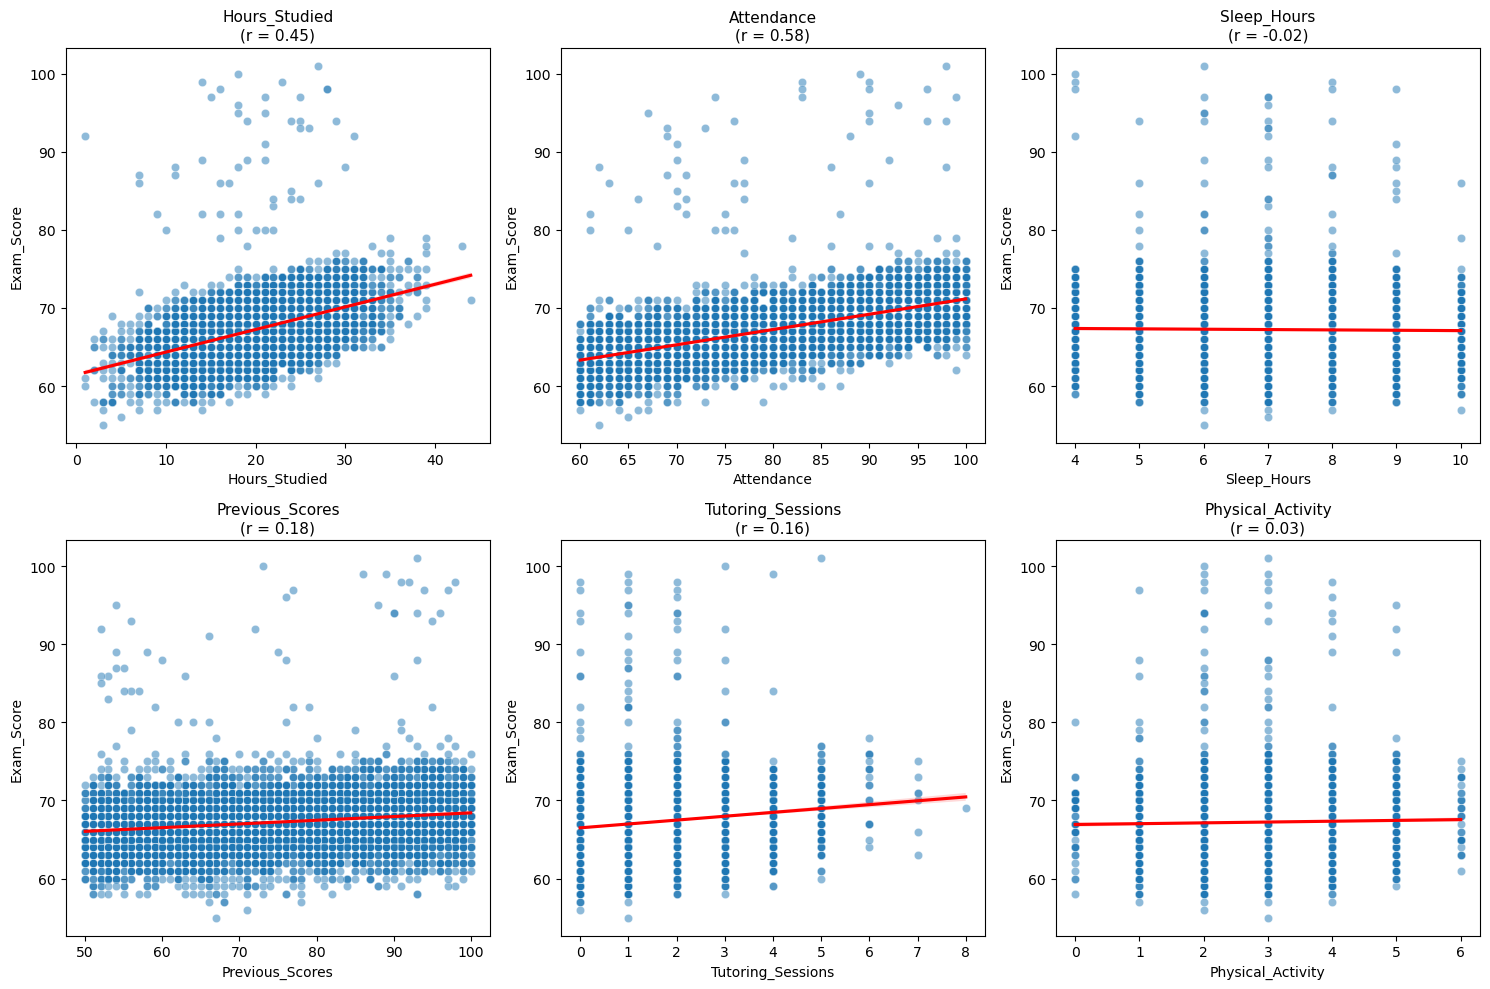

In [119]:
# Fixed numerical analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    corr = df[col].corr(df['Exam_Score'])
    
    sns.scatterplot(x=df[col], y=df['Exam_Score'], alpha=0.5, ax=axes[idx])
    sns.regplot(x=df[col], y=df['Exam_Score'], scatter=False, color='red', ax=axes[idx])
    axes[idx].set_title(f'{col}\n(r = {corr:.2f})', fontsize=11)
    
    # Fixed binning with duplicate handling
    try:
        df_analysis[f'{col}_bin'] = pd.qcut(df[col], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')
        binned_means = df_analysis.groupby(f'{col}_bin', observed=False)['Exam_Score'].mean().round(2)
        print(f"\n📈 {col}: r={corr:.3f}")
        for level, mean_score in binned_means.items():
            print(f"    {level}: {mean_score}")
    except Exception as e:
        print(f"\n📈 {col}: r={corr:.3f} (binning skipped: {str(e)[:50]})")

plt.tight_layout()
plt.show()

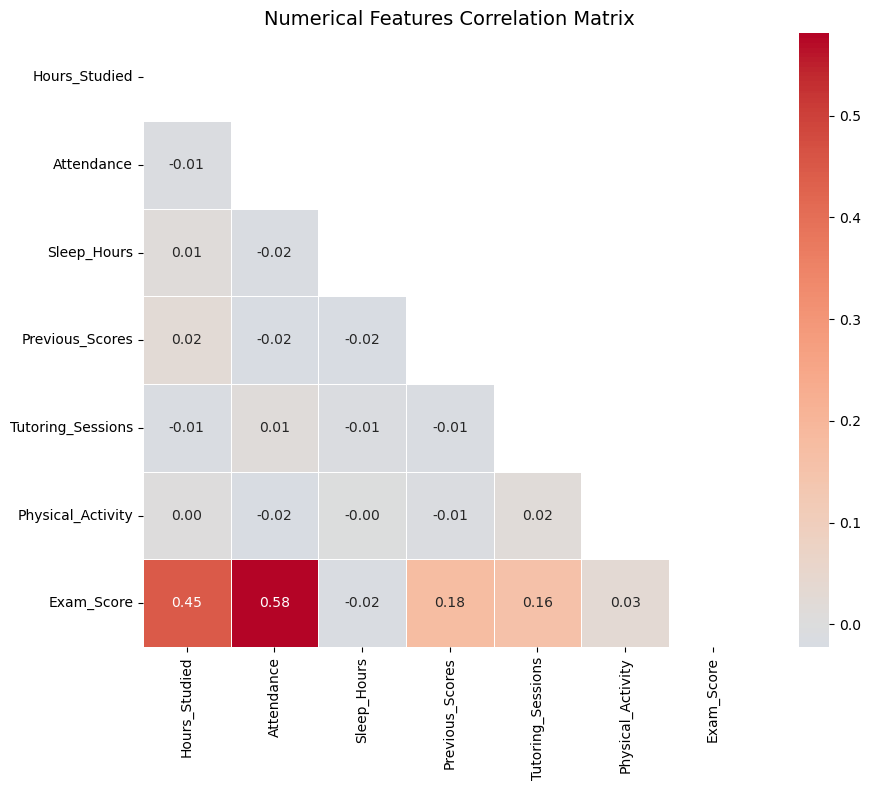


Features most correlated with Exam Score:
  Attendance: 0.581
  Hours_Studied: 0.445
  Previous_Scores: 0.175
  Tutoring_Sessions: 0.157
  Physical_Activity: 0.028
  Sleep_Hours: -0.017


In [125]:
plt.figure(figsize=(10, 8))
numeric_df = df[numerical_cols + ['Exam_Score']]
correlation_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
            center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Numerical Features Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Find top correlations with target
target_corrs = correlation_matrix['Exam_Score'].sort_values(ascending=False)
print("\nFeatures most correlated with Exam Score:")
for feature, corr_value in target_corrs.items():
    if feature != 'Exam_Score':
        print(f"  {feature}: {corr_value:.3f}")

## OUTLIER DETECTION

In [126]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

OUTLIER DETECTION
Hours_Studied: 43 outliers (0.7%)
Attendance: 0 outliers (0.0%)
Sleep_Hours: 0 outliers (0.0%)
Previous_Scores: 0 outliers (0.0%)
Tutoring_Sessions: 430 outliers (6.5%)
Physical_Activity: 0 outliers (0.0%)


In [127]:
# Check the distribution of Tutoring_Sessions
print(df['Tutoring_Sessions'].value_counts().sort_index())
print(f"\nUnique values: {df['Tutoring_Sessions'].unique()}")
print(f"Max value: {df['Tutoring_Sessions'].max()}")

Tutoring_Sessions
0    1513
1    2179
2    1649
3     836
4     301
5     103
6      18
7       7
8       1
Name: count, dtype: int64

Unique values: [0 2 1 3 4 5 6 7 8]
Max value: 8


In [133]:
# Check if high tutoring actually leads to higher scores
print("Exam scores by tutoring sessions:")
print(df.groupby('Tutoring_Sessions')['Exam_Score'].agg(["mean","count"]))

Exam scores by tutoring sessions:
                        mean  count
Tutoring_Sessions                  
0                  66.489755   1513
1                  66.980266   2179
2                  67.567010   1649
3                  67.894737    836
4                  68.229236    301
5                  69.067961    103
6                  71.666667     18
7                  69.857143      7
8                  69.000000      1


# Outlier Assessment

### Tutoring_Sessions
- Values: **6, 7, 8** (26 students, 0.4% of data)  
- Pattern shows: **6 sessions → 71.67 score (+5.2 points over baseline)**  
- These represent real high-achieving students with intensive tutoring  

---

## Decision
✅ **KEEP ALL OUTLIERS**

---

## Reasoning
1. Outliers represent valid real-world patterns  
2. Removing them hides the insight that 6 sessions is optimal  
3. Random Forest is robust to outliers  
4. Small sample size (26 students) doesn't justify removal  
5. Preserves ability to predict for high-tutoring students  


## PREPARE FOR MODELING

In [169]:
# Remove temporary bin columns
df = df.drop([col for col in df.columns if col.endswith('_bin')], axis=1)

In [158]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [170]:
X = df.drop('Exam_Score',axis = 1)
y = df['Exam_Score']

In [171]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (6607, 19)
Target shape: (6607,)


#### Create preprocessing pipeline

In [172]:
preprocessor  = ColumnTransformer ([
    ("num",StandardScaler(),numeric_cols),
    ("cat" , OneHotEncoder(drop='first',sparse_output=False,handle_unknown="ignore") ,categorical_cols)])


In [173]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [175]:
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 5285 samples
Test set: 1322 samples


## MODEL TRAINING & COMPARISON

In [184]:
models = {
    'Linear Regression':LinearRegression(),
    'Random Forest' : RandomForestRegressor(n_estimators=100,random_state=42)
}

In [185]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore"), categorical_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


In [188]:
results = {}
predictions = {}
for name,model in models.items():
    pipeline = Pipeline([
        ('preprocessor',preprocessor),
        ('regressor',model)
    ])
    pipeline.fit(X_train,y_train)
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    r2 = r2_score(y_test,y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    predictions[name] = y_pred
    print(f"\n{name}:")
    print(f"  MAE:  {mae:.2f} (off by {mae:.1f} points on average)")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²:   {r2:.3f} ({r2*100:.1f}% variance explained)")


Linear Regression:
  MAE:  0.45 (off by 0.4 points on average)
  RMSE: 1.80
  R²:   0.770 (77.0% variance explained)

Random Forest:
  MAE:  1.18 (off by 1.2 points on average)
  RMSE: 2.23
  R²:   0.649 (64.9% variance explained)



VISUALIZING MODEL PREDICTIONS


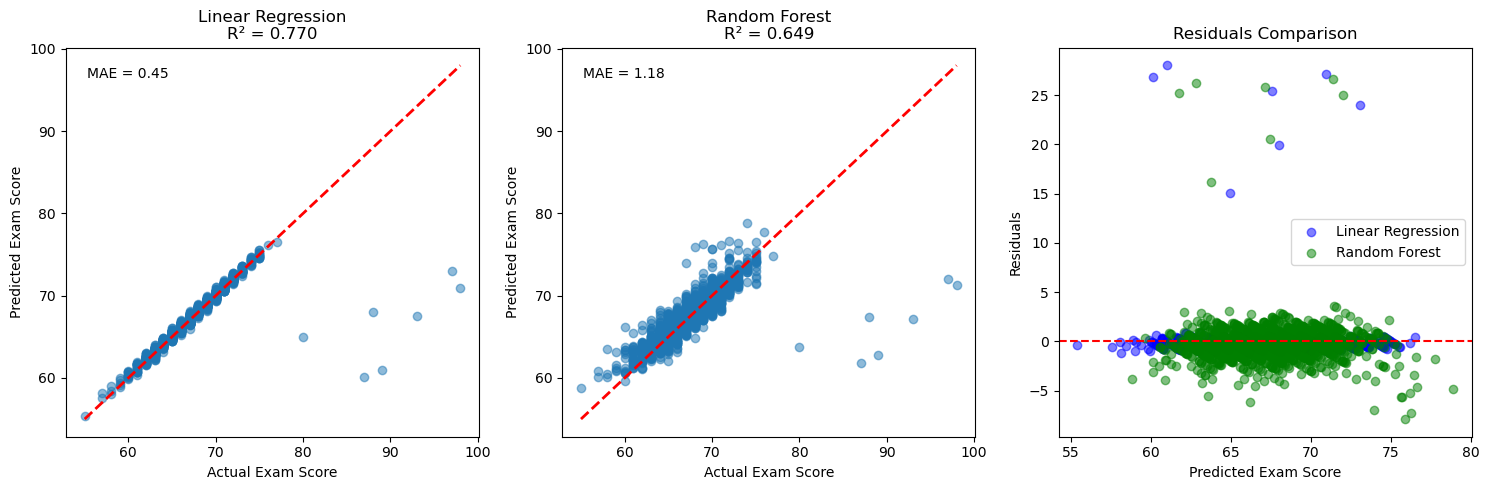

In [187]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Linear Regression\nR² = {result["Linear Regression"]["R2"]:.3f}')
axes[0].text(0.05, 0.95, f'MAE = {results["Linear Regression"]["MAE"]:.2f}',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top')

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title(f'Random Forest\nR² = {results["Random Forest"]["R2"]:.3f}')
axes[1].text(0.05, 0.95, f'MAE = {results["Random Forest"]["MAE"]:.2f}',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top')

# Residuals
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf
axes[2].scatter(y_pred_lr, residuals_lr, alpha=0.5, label='Linear Regression', color='blue')
axes[2].scatter(y_pred_rf, residuals_rf, alpha=0.5, label='Random Forest', color='green')
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title('Residuals Comparison')
axes[2].legend()

plt.tight_layout()
plt.show()
